<a href="https://colab.research.google.com/github/FernandoPulidoM/Inteligencia_Computacional_Actividad5/blob/main/5_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [ ]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "./data/" if IN_COLAB else "../data/asl_data/"


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [ ]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

In [ ]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

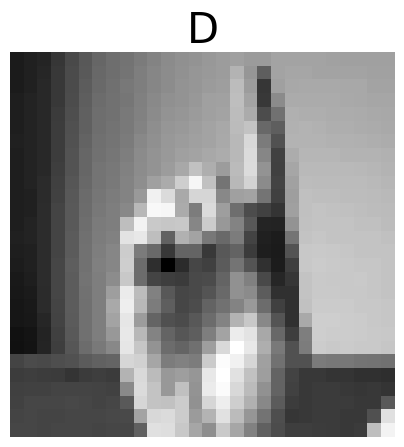

In [ ]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [ ]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [ ]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [ ]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well.

In [ ]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [ ]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [ ]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [ ]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512), #capa
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512), #capa
    nn.ReLU(),
    nn.Linear(512, 24) #capa
    #3 capas
)

model_fcnn = model_fcnn.to(device)

In [ ]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:41<00:00,  2.09s/epoch, train_acc=0.8597, train_loss=0.4053, val_acc=0.7175, val_loss=1.0932]


In [ ]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [ ]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28 =  # 2 filtros, nn.Conv2d(in_channels, out_channels, kernel_size, ...)
    nn.ReLU(),                                      # K x ( C x k x k + 1)
    nn.MaxPool2d(2, stride=2),                      # 25 x ( 1 x 3 x 3 + 1  )

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),

    nn.Flatten(),                   # 75 * 3 * 3 = 675
    nn.Linear(75 * 3 * 3, 512), # capa 1 (675 x 512)    +  512
    nn.Dropout(.3),                    #   ( in x out ) + out
    nn.ReLU(),
    nn.Linear(512, 24) # capa 2
)

model_cnn = model_cnn.to(device)

In [ ]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:53<00:00,  2.68s/epoch, train_acc=0.9968, train_loss=0.0110, val_acc=0.9529, val_loss=0.1689]


In [ ]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

## Reflection section

### Which model is better at classifying ASL images?



FCNN:
Training: 100%|██████████| 20/20 [00:41<00:00,  2.09s/epoch, train_acc=0.8597, train_loss=0.4053, val_acc=0.7175, val_loss=1.0932]

CNN:
Training: 100%|██████████| 20/20 [00:53<00:00,  2.68s/epoch, train_acc=0.9968, train_loss=0.0110, val_acc=0.9529, val_loss=0.1689]

CNN es mejor. Podemos ver que CNN tiene más accuracy, en train y val. Y tambien menos loss.

### Which model was _faster_ to train?

fcnn fueron 18 segundos

cnn fueron 24 segundos

fcnn fue más rápido

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

In [ ]:
#codigo de la presentacion de learning curves

import matplotlib.pyplot as plt

def plot_learning_curves(train_losses, val_losses):

  epochs = range(1, 20 + 1)
  plt.plot(epochs, train_losses, label="Train Loss")
  plt.plot(epochs, val_losses, label="Validation Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title("Learning Curves")
  plt.legend()
  plt.show()

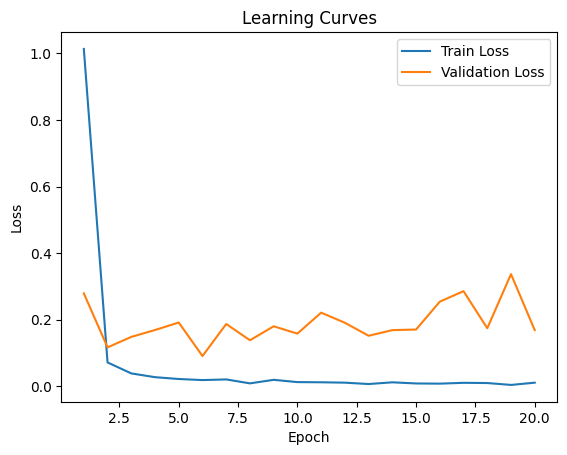

In [ ]:
plot_learning_curves(cnn_res['train_loss'], cnn_res['val_loss'])

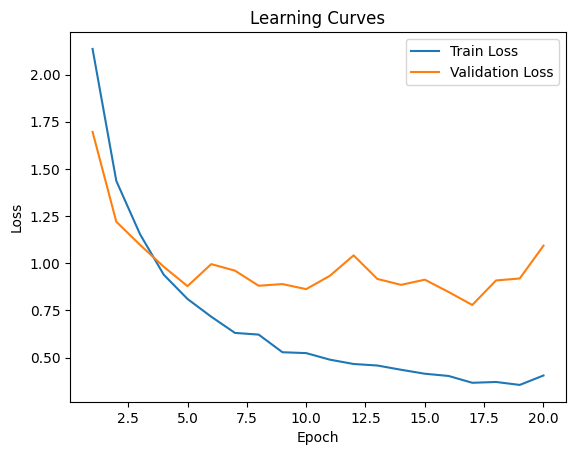

In [ ]:
plot_learning_curves(fcnn_res['train_loss'], fcnn_res['val_loss'])

Podemos ver que En CNN, en train loss baja de 1 a casi 0.1 y se queda ahi estable.

Es similar con fcnn, donde el train loss baja de 2.2 a menos de 0.5 en cuestion de tiempo.

Se nota que en train loss y val loss tienen actitudes similares en los dos modelos donde el train loss se reduce por epoch pero el validation loss sube y baja por cada epoch.

Parece ser caso de overfitting en ambos modelos

### How many trainable parameters does each model have?

Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

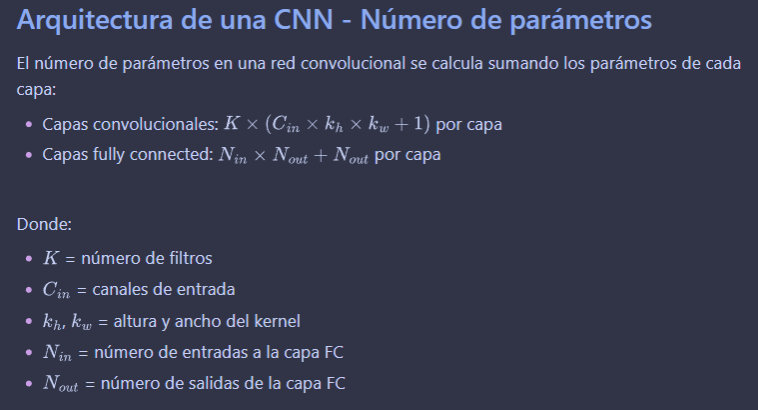

#FCNN MODEL

1. nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512)

IMG_HEIGHT = 28
IMG_WIDTH = 28

In = 784
formula:

( in x out ) + out

(784 x 512)    +  512

401920 parametros

2. nn.Linear(512, 512), #capa

formula:

( in x out ) + out

(512 x 512)    +  512

262656 parametros

3. nn.Linear(512, 24) #capa

formula:

( in x out ) + out

(512 x 24)    +  24
12312 parametros

4. Total de parametros en modelo

401920 + 262656 + 12312

676888 parametros


#CNN MODEL

1. nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),

formula:

K x ( C x k x k + 1)

25 x ( 1 x 3 x 3 + 1  )

250 parametros

2. nn.Conv2d(25, 50, 3, stride=1, padding=1)

formula:

K x ( C x k x k + 1)

50 x ( 25 x 3 x 3 + 1  )

11300 parametros

3. nn.Conv2d(50, 75, 3, stride=1, padding=1)

formula:

K x ( C x k x k + 1)

75 x ( 50 x 3 x 3 + 1  )

33825 parametros

4. nn.Linear(75 * 3 * 3, 512),

75 * 3 * 3 = 675

formula:

( in x out ) + out

(675 x 512)    +  512

346112 parametros

5. nn.Linear(512, 24)

formula:

( in x out ) + out

(512 x 24)    +  24

12312 parametros


6. SUMA FINAL DEL MODELO:

250 + 11300 + 33825 + 346112 + 12312

403799 Parametros

### How do the models compare in terms of overfitting? Why do you think that is the case?

Los dos tienen overfitting, se bajan los train loss por epoch pero a la hora de validar son más inconsistentes. Sube y baja. Considero que sucede por que son muchos parametros, siento que se memoriza el dataset enves de aprender de ello. Se refleja como el mejor modelo tiene menos parametros. Estoy seguro que hay mas factores pero considero que es el principal.

### Final conclusions and remarks

En esta actividad se pudo ver como dos modelos distintos donde uno es claramente más eficiente que el otro pueden caer en overfitting por su cantidad de parametros. Los dos usan el mismo proceso de train pero arquitectura de modelo los lleva a niveles distintos accuracy y loss. La nueva arquitectura CNN, aunque tarde más en compilar es mejor en todo lo demás y se pudiera ajustar para evitar el overfitting actual que tiene.


Tambien en otro tema, se pudo comparar y entender bien las formulas de suma de parametros sea para convolucionales o fully connected.